# 03 Bayesian Network (paper-aligned)

- Φορτώνουμε τα paper-aligned train/test datasets
- Εκπαιδεύουμε Bayesian Network (BN) στο train set
- Κάνουμε πρόβλεψη στο test set για τη μεταβλητή-στόχο `duration_class`
- Αξιολογούμε την απόδοση με κατάλληλες μετρικές για multi-class imbalance
  (Accuracy, Macro F1, Confusion Matrix, per-class report)


In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
PROCESSED_DIR = ROOT / "API-Data" / "processed"

TRAIN_CSV = PROCESSED_DIR / "dataset_paper_train.csv"
TEST_CSV  = PROCESSED_DIR / "dataset_paper_test.csv"

print("Reading:", TRAIN_CSV)
train_df = pd.read_csv(TRAIN_CSV)

print("Reading:", TEST_CSV)
test_df = pd.read_csv(TEST_CSV)

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

display(train_df.head(3))


Reading: C:\Users\georg\Desktop\Ergasia Sgouros_v0.3_Final\API-Data\processed\dataset_paper_train.csv
Reading: C:\Users\georg\Desktop\Ergasia Sgouros_v0.3_Final\API-Data\processed\dataset_paper_test.csv

Train shape: (122002, 25)
Test shape: (7483, 25)

Columns:
['Flag', 'ShipType', 'PSCInspectionType', 'PlaceOfInspection', 'ReportingAuthority', 'ship_age_group', 'gt_group', 'def_grp_01', 'def_grp_02', 'def_grp_03', 'def_grp_04', 'def_grp_05', 'def_grp_06', 'def_grp_07', 'def_grp_08', 'def_grp_09', 'def_grp_10', 'def_grp_11', 'def_grp_12', 'def_grp_13', 'def_grp_14', 'def_grp_15', 'def_grp_16', 'def_grp_17', 'duration_class']


,Flag,ShipType,PSCInspectionType,PlaceOfInspection,ReportingAuthority,ship_age_group,gt_group,def_grp_01,def_grp_02,def_grp_03,...,def_grp_09,def_grp_10,def_grp_11,def_grp_12,def_grp_13,def_grp_14,def_grp_15,def_grp_16,def_grp_17,duration_class
0,MT,330,INITIAL_INSPECTION,NLRTM,NL,10-14,2000-9999,0,1,1,...,0,0,1,0,0,0,0,0,0,0 day
1,MD,360,DETAILED_INSPECTION,ITCHI,IT,5-9,2000-9999,1,0,0,...,0,1,1,0,0,0,1,0,0,6-7 days
2,AG,353,DETAILED_INSPECTION,NLRTM,NL,5-9,2000-9999,0,0,0,...,0,0,1,0,1,0,0,0,0,0 day


### preprocess για Bayesian Network

Τα Bayesian Networks στο `pgmpy` δουλεύουν σε διακριτές μεταβλητές.
- μετατρέπουμε όλες τις στήλες σε κατηγορικές (strings)
- κρατάμε τη μεταβλητή στόχο `duration_class`


In [2]:
TARGET = "duration_class"

#copy gia na min peiraksoume ta arxika dataframes
train_bn = train_df.copy()
test_bn = test_df.copy()

#ola se strings gia DiscreteBN
for c in train_bn.columns:
    train_bn[c] = train_bn[c].astype(str)
    test_bn[c] = test_bn[c].astype(str)

print("Unique classes in target (train):", train_bn[TARGET].nunique())
print("Unique classes in target (test):", test_bn[TARGET].nunique())
print("Target labels (train):", sorted(train_bn[TARGET].unique())[:20])


Unique classes in target (train): 9
Unique classes in target (test): 9
Target labels (train): ['0 day', '1-2 days', '11-17 days', '18+ days', '3 days', '4 days', '5 days', '6-7 days', '8-10 days']


### Εκμάθηση δομής Bayesian Network (Structure Learning)

Στο paper, η δομή του BN μπορεί να προκύπτει είτε:
- από γνώση πεδίου (domain knowledge), είτε
- από αλγορίθμους structure learning.


## Naive Bayes Bayesian Network (Fixed structure)

Για να αποφύγουμε προβλήματα από unconstrained structure learning και να έχουμε
paper-like baseline, φτιάχνουμε ένα Naive Bayes Bayesian Network:

- Όλα τα χαρακτηριστικά → `duration_class` (target)
- Δεν υπάρχουν ακμές μεταξύ features
- Χρησιμοποιούμε Bayesian parameter learning με prior (BDeu) για πιο σταθερές πιθανότητες
  (πιο κοντά σε MAP από MLE)


In [3]:
from pgmpy.models import DiscreteBayesianNetwork

TARGET = "duration_class"
FEATURES = [c for c in train_bn.columns if c != TARGET]

# Greeklish comments:
# Sosto Naive Bayes BN: TARGET -> feature
nb_edges = [(TARGET, f) for f in FEATURES]

nb_model = DiscreteBayesianNetwork(nb_edges)

print("NB model nodes:", len(nb_model.nodes()))
print("NB model edges:", len(nb_model.edges()))
print("Sample edges:", nb_edges[:5])


C:\Users\georg\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NB model nodes: 25
NB model edges: 24
Sample edges: [('duration_class', 'Flag'), ('duration_class', 'ShipType'), ('duration_class', 'PSCInspectionType'), ('duration_class', 'PlaceOfInspection'), ('duration_class', 'ReportingAuthority')]


### Προστασία από "unseen categories" στο test set

Αν στο test εμφανιστεί κατηγορία που δεν υπήρχε στο train (π.χ. νέο `PlaceOfInspection`),
τότε το BN μπορεί να δυσκολευτεί στο inference.

Για να το αποφύγουμε:
- για κάθε categorical feature, αν στο test υπάρχει τιμή που δεν υπάρχει στο train,
  την αντικαθιστούμε με την πιο συχνή τιμή του train (mode).


In [4]:
allowed = {}
mode_value = {}

for c in FEATURES:
    allowed[c] = set(train_bn[c].unique())
    mode_value[c] = train_bn[c].mode()[0]

test_nb = test_bn.copy()

unseen_total = 0
for c in FEATURES:
    mask_unseen = ~test_nb[c].isin(allowed[c])
    unseen_count = int(mask_unseen.sum())
    unseen_total += unseen_count
    if unseen_count > 0:
        test_nb.loc[mask_unseen, c] = mode_value[c]

print("Total unseen value replacements in test:", unseen_total)


Total unseen value replacements in test: 35


## Εκμάθηση παραμέτρων με Bayesian Estimator (BDeu prior)

Χρησιμοποιούμε BayesianEstimator με BDeu prior ώστε:
- να αποφύγουμε μηδενικές πιθανότητες
- να έχουμε πιο σταθερές εκτιμήσεις σε σπάνιες κλάσεις
- να προσεγγίσουμε τη λογική MAP (σε αντίθεση με καθαρό MLE)


In [5]:
from pgmpy.estimators import BayesianEstimator

# Tora oi CPDs einai P(feature | target), opote den ginontai terasties
nb_model.fit(
    train_bn,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

print("NB BN trained with BayesianEstimator (BDeu).")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Flag': 'C', 'ShipType': 'C', 'PSCInspectionType': 'C', 'PlaceOfInspection': 'C', 'ReportingAuthority': 'C', 'ship_age_group': 'C', 'gt_group': 'C', 'def_grp_01': 'C', 'def_grp_02': 'C', 'def_grp_03': 'C', 'def_grp_04': 'C', 'def_grp_05': 'C', 'def_grp_06': 'C', 'def_grp_07': 'C', 'def_grp_08': 'C', 'def_grp_09': 'C', 'def_grp_10': 'C', 'def_grp_11': 'C', 'def_grp_12': 'C', 'def_grp_13': 'C', 'def_grp_14': 'C', 'def_grp_15': 'C', 'def_grp_16': 'C', 'def_grp_17': 'C', 'duration_class': 'C'}


NB BN trained with BayesianEstimator (BDeu).


## Πρόβλεψη στο test set (Naive Bayes BN)

Κάνουμε MAP πρόβλεψη για το `duration_class` χρησιμοποιώντας ως evidence όλα τα features.


In [6]:
from pgmpy.inference import VariableElimination

nb_infer = VariableElimination(nb_model)

y_true_nb = test_nb[TARGET].tolist()
y_pred_nb = []

fallback_class = train_bn[TARGET].mode()[0]
errors = 0

def nb_predict_one_row(row):
    evidence = row.drop(TARGET).to_dict()
    q = nb_infer.map_query([TARGET], evidence=evidence, show_progress=False)
    return q[TARGET]

for _, r in test_nb.iterrows():
    try:
        y_pred_nb.append(nb_predict_one_row(r))
    except Exception:
        errors += 1
        y_pred_nb.append(fallback_class)

print("Predictions done.")
print("Inference errors (fallback used):", errors)


Predictions done.
Inference errors (fallback used): 0


## Αξιολόγηση Naive Bayes BN (Accuracy, Macro F1, Weighted F1)

Λόγω multi-class imbalance, δίνουμε έμφαση σε Macro F1 και per-class metrics.


In [7]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

acc_nb = accuracy_score(y_true_nb, y_pred_nb)
f1_macro_nb = f1_score(y_true_nb, y_pred_nb, average="macro")
f1_weighted_nb = f1_score(y_true_nb, y_pred_nb, average="weighted")

print("Accuracy:", round(acc_nb, 4))
print("Macro F1:", round(f1_macro_nb, 4))
print("Weighted F1:", round(f1_weighted_nb, 4))

print("\nClassification report:")
print(classification_report(y_true_nb, y_pred_nb, digits=3))

cm_nb = confusion_matrix(y_true_nb, y_pred_nb)
print("\nConfusion matrix:")
print(cm_nb)


Accuracy: 0.9036
Macro F1: 0.1903
Weighted F1: 0.9271

Classification report:
              precision    recall  f1-score   support

       0 day      0.991     0.936     0.962      7174
    1-2 days      0.053     0.071     0.061        28
  11-17 days      0.140     0.286     0.188        49
    18+ days      0.213     0.260     0.234        50
      3 days      0.032     0.167     0.053        30
      4 days      0.031     0.061     0.041        33
      5 days      0.027     0.067     0.038        30
    6-7 days      0.044     0.109     0.063        46
   8-10 days      0.052     0.116     0.071        43

    accuracy                          0.904      7483
   macro avg      0.176     0.230     0.190      7483
weighted avg      0.953     0.904     0.927      7483


Confusion matrix:
[[6714   29   62   29  122   39   50   82   47]
 [  17    2    0    2    3    1    2    1    0]
 [   1    0   14   12    4    5    2    3    8]
 [   3    1    6   13    3    2    2    5   15]
 [  13

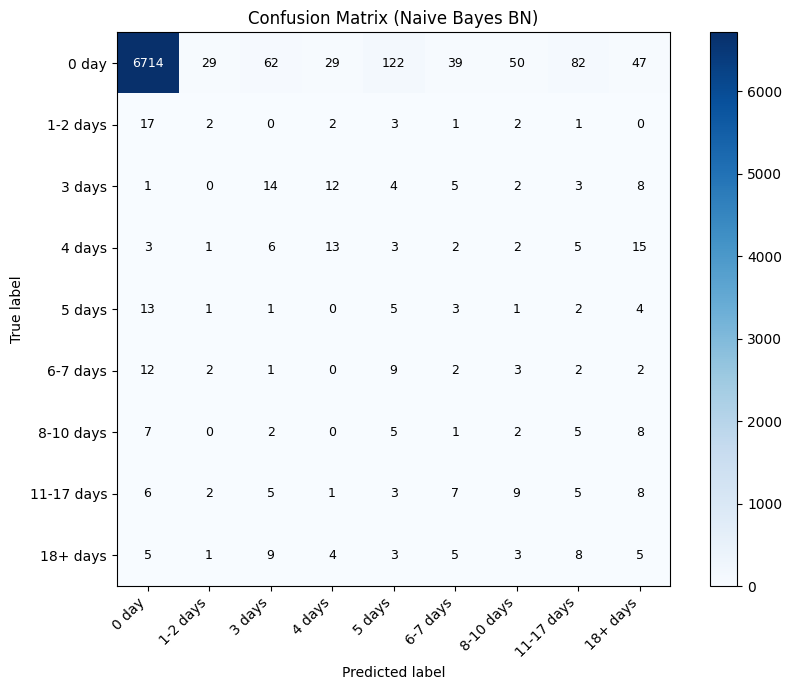

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_true_nb, y_pred_nb)

labels = ["0 day", "1-2 days", "3 days", "4 days", "5 days", "6-7 days", "8-10 days", "11-17 days", "18+ days"]

plt.figure(figsize=(9, 7))
plt.imshow(cm_nb, cmap="Blues")
plt.title("Confusion Matrix (Naive Bayes BN)")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

max_val = cm_nb.max() if cm_nb.max() > 0 else 1
threshold = max_val * 0.5

for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        val = cm_nb[i, j]
        color = "white" if val > threshold else "black"
        plt.text(j, i, str(val), ha="center", va="center", color=color, fontsize=9)

plt.colorbar()
plt.tight_layout()
plt.show()
